In [1]:
!pip install nltk tensorflow pandas numpy matplotlib scikit-learn transformers datasets networkx gensim rouge-score pypdf

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 55.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 349.5/349.5 kB 16.9 MB/s eta 0:00:00
  Created wheel for rouge-score: filename=rouge_score-0.1.2-py3-none-any.whl size=24934 sha256=9f79744dfc42a5c6e01182e900a34316e1ec13c8f9813ca92f4a0733ee89584a
  Stored in directory: /root/.cache/pip/wheels/85/9d/af/01feefbe7d55ef5468796f0c68225b6788e85d9d0a281e7a70
Successfully built rouge-score


In [2]:
import numpy as np
import pandas as pd
import re
import networkx as nx
import matplotlib.pyplot as plt
from pypdf import PdfReader

# NLP Essentials
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import sent_tokenize, word_tokenize
from sklearn.metrics.pairwise import cosine_similarity

# Transformers & Embeddings
from sentence_transformers import SentenceTransformer
from transformers import pipeline, T5Tokenizer, T5ForConditionalGeneration
from rouge_score import rouge_scorer
from datasets import load_dataset

# Deep Learning (LSTM Encoder-Decoder)
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, LSTM, Embedding, Dense, Concatenate

# TextRank / Word Vectors
from gensim.models import Word2Vec
from sklearn.metrics.pairwise import cosine_similarity

# PDF
from pypdf import PdfReader

# Download NLTK resources
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')

print("Libraries imported and NLTK resources ready!")


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...


Libraries imported and NLTK resources ready!


[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


LOAD INPUT DATA

In [3]:
# NOTE: 'cnn_dailymail' (no namespace) uses an old loading-script format that
# raises HfUriError with current huggingface_hub versions. 'abisee/cnn_dailymail'
# is the namespaced, Parquet-based mirror of the same dataset (same columns:
# 'article', 'highlights') and works with modern tooling.
dataset = load_dataset("abisee/cnn_dailymail", "3.0.0")

train_data = dataset['train'].select(range(300))
test_data = dataset['test'].select(range(50))

README.md:   0%|          | 0.00/15.6k [00:00<?, ?B/s]

3.0.0/train-00000-of-00003.parquet:   0%|          | 0.00/257M [00:00<?, ?B/s]

3.0.0/train-00001-of-00003.parquet:   0%|          | 0.00/257M [00:00<?, ?B/s]

3.0.0/train-00002-of-00003.parquet:   0%|          | 0.00/259M [00:00<?, ?B/s]

3.0.0/validation-00000-of-00001.parquet:   0%|          | 0.00/34.7M [00:00<?, ?B/s]

3.0.0/test-00000-of-00001.parquet:   0%|          | 0.00/30.0M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/287113 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/13368 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/11490 [00:00<?, ? examples/s]

In [4]:
df = pd.DataFrame(train_data)

def preprocess_text(text):
    text = text.lower()
    text = text.replace("\n", " ").replace("\t", " ")
    text = re.sub(r'[^a-zA-Z0-9 ]', '', text)
    text = re.sub(r'\s+', ' ', text)
    return text.strip()


df['clean_article'] = df['article'].apply(preprocess_text)

df['clean_summary'] = df['highlights'].apply(
    lambda x: "startseq " + preprocess_text(x) + " endseq"
)


print("\nCleaned Article:\n", df['clean_article'][0])
print("\nCleaned Summary:\n", df['clean_summary'][0])


Cleaned Article:
 london england reuters harry potter star daniel radcliffe gains access to a reported 20 million 411 million fortune as he turns 18 on monday but he insists the money wont cast a spell on him daniel radcliffe as harry potter in harry potter and the order of the phoenix to the disappointment of gossip columnists around the world the young actor says he has no plans to fritter his cash away on fast cars drink and celebrity parties i dont plan to be one of those people who as soon as they turn 18 suddenly buy themselves a massive sports car collection or something similar he told an australian interviewer earlier this month i dont think ill be particularly extravagant the things i like buying are things that cost about 10 pounds books and cds and dvds at 18 radcliffe will be able to gamble in a casino buy a drink in a pub or see the horror film hostel part ii currently six places below his number one movie on the uk box office chart details of how hell mark his landmark 

**TEXTRANK**

In [5]:
def textrank_summary(text, num_sentences=3):
    try:
        # FIX: previously this referenced the undefined variable 'clean_article'
        # instead of the 'text' argument, which raised a NameError every call
        # and silently fell back to the except block below (text[:200]).
        sentences = sent_tokenize(text)
        if len(sentences) < 2:
            return text[:200]

        tokenized = [s.split() for s in sentences if len(s.split()) > 2]

        model = Word2Vec(tokenized, vector_size=50, min_count=1)

        sentence_vectors = []
        for sentence in tokenized:
            vec = np.zeros(50)
            for word in sentence:
                if word in model.wv:
                    vec += model.wv[word]
            vec /= (len(sentence) + 1)
            sentence_vectors.append(vec)

        sim_matrix = np.zeros((len(sentence_vectors), len(sentence_vectors)))

        for i in range(len(sentence_vectors)):
            for j in range(len(sentence_vectors)):
                if i != j:
                    sim_matrix[i][j] = cosine_similarity(
                        sentence_vectors[i].reshape(1, -1),
                        sentence_vectors[j].reshape(1, -1)
                    )[0][0]

        nx_graph = nx.from_numpy_array(sim_matrix)
        scores = nx.pagerank(nx_graph)

        ranked = sorted(((scores[i], s) for i, s in enumerate(sentences)), reverse=True)

        return " ".join([ranked[i][1] for i in range(min(num_sentences, len(ranked)))])

    except:
        return text[:200]

In [6]:
sample = test_data[0]

text = sample['article'][:500]

print("Original Text:\n")
print(text)

print("\nTEXTRANK SUMMARY:\n")
print(textrank_summary(text))

Original Text:

(CNN)The Palestinian Authority officially became the 123rd member of the International Criminal Court on Wednesday, a step that gives the court jurisdiction over alleged crimes in Palestinian territories. The formal accession was marked with a ceremony at The Hague, in the Netherlands, where the court is based. The Palestinians signed the ICC's founding Rome Statute in January, when they also accepted its jurisdiction over alleged crimes committed "in the occupied Palestinian territory, includin

TEXTRANK SUMMARY:

The Palestinians signed the ICC's founding Rome Statute in January, when they also accepted its jurisdiction over alleged crimes committed "in the occupied Palestinian territory, includin (CNN)The Palestinian Authority officially became the 123rd member of the International Criminal Court on Wednesday, a step that gives the court jurisdiction over alleged crimes in Palestinian territories. The formal accession was marked with a ceremony at The Hague, in the N

**LSTM** **MODEL**

In [7]:
# Max length
max_article_len = 100
max_summary_len = 20

#tokenizer
tokenizer = Tokenizer()
tokenizer.fit_on_texts(list(df['clean_article']) + list(df['clean_summary']))

# article_seq = tokenizer.texts_to_sequences(...)
X_seq = tokenizer.texts_to_sequences(list(df['clean_article']))
# summary_seq = tokenizer.texts_to_sequences(...)
y_seq = tokenizer.texts_to_sequences(list(df['clean_summary']))

#padding
X_pad = pad_sequences(X_seq, maxlen = max_article_len, padding='post')
y_pad = pad_sequences(y_seq, maxlen = max_summary_len, padding='post')

# Vocabulary size
vocab_size = len(tokenizer.word_index) + 1

In [8]:
# encoder_input = ...
encoder_input_data = X_pad
# decoder_input = ...
decoder_input_data = y_pad[:, :-1]
# decoder_output = ...
decoder_target_data = y_pad[:, 1:]

print("Shape of Encoder Input:", encoder_input_data.shape)
print("Shape of Decoder Input:", decoder_input_data.shape)

Shape of Encoder Input: (300, 100)
Shape of Decoder Input: (300, 19)


In [9]:
latent_dim = 256 # Hidden units

# --- ENCODER ---
enc_input = Input(shape=(max_article_len,))
enc_emb = Embedding(vocab_size, latent_dim, trainable=True)(enc_input)
enc_lstm = LSTM(latent_dim, return_state=True)
enc_outputs, state_h, state_c = enc_lstm(enc_emb)
enc_states = [state_h, state_c]

# --- DECODER ---
dec_input = Input(shape=(None,))
dec_emb_layer = Embedding(vocab_size, latent_dim, trainable=True)
dec_emb = dec_emb_layer(dec_input)
dec_lstm = LSTM(latent_dim, return_sequences=True, return_state=True)
dec_outputs, _, _ = dec_lstm(dec_emb, initial_state=enc_states)

# --- DENSE LAYER (Output) ---
dec_dense = Dense(vocab_size, activation='softmax')
dec_outputs = dec_dense(dec_outputs)

# Define Model
model = Model([enc_input, dec_input], dec_outputs)
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 100)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_1       │ (None, None)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 100, 256)  │  4,399,616 │ input_layer[0][0] │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_1         │ (None, None, 256) │  4,399,616 │ input_layer_1[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm (LSTM)         │ [(None, 256),     │    525,312 │ embedding[0][0]   │
│                     │ (None, 256),      │            │                   │
│                     │ (None, 256)]      │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_1 (LSTM)       │ [(None, None,     │    525,312 │ embedding_1[0][0… │
│                     │ 256), (None,      │            │ lstm[0][1],       │
│                     │ 256), (None,      │            │ lstm[0][2]        │
│                     │ 256)]             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, None,      │  4,416,802 │ lstm_1[0][0]      │
│                     │ 17186)            │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 14,266,658 (54.42 MB)

 Trainable params: 14,266,658 (54.42 MB)

 Non-trainable params: 0 (0.00 B)

In [11]:
#compilation of model
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy']
)

#train model
history = model.fit(
    [encoder_input_data, decoder_input_data],
    decoder_target_data,
    epochs=10,
    batch_size=2,
    verbose=1
)

Epoch 1/10
150/150 ━━━━━━━━━━━━━━━━━━━━ 65s 421ms/step - accuracy: 0.1026 - loss: 6.1561
Epoch 2/10
150/150 ━━━━━━━━━━━━━━━━━━━━ 82s 422ms/step - accuracy: 0.1116 - loss: 5.6108
Epoch 3/10
150/150 ━━━━━━━━━━━━━━━━━━━━ 83s 430ms/step - accuracy: 0.1175 - loss: 5.3208
Epoch 4/10
150/150 ━━━━━━━━━━━━━━━━━━━━ 65s 432ms/step - accuracy: 0.1174 - loss: 5.2805
Epoch 5/10
150/150 ━━━━━━━━━━━━━━━━━━━━ 81s 426ms/step - accuracy: 0.1458 - loss: 4.7559
Epoch 6/10
150/150 ━━━━━━━━━━━━━━━━━━━━ 65s 430ms/step - accuracy: 0.1691 - loss: 4.3864
Epoch 7/10
150/150 ━━━━━━━━━━━━━━━━━━━━ 61s 405ms/step - accuracy: 0.2063 - loss: 4.0407
Epoch 8/10
150/150 ━━━━━━━━━━━━━━━━━━━━ 83s 410ms/step - accuracy: 0.2609 - loss: 3.7051
Epoch 9/10
150/150 ━━━━━━━━━━━━━━━━━━━━ 62s 416ms/step - accuracy: 0.3333 - loss: 3.3721
Epoch 10/10
150/150 ━━━━━━━━━━━━━━━━━━━━ 64s 424ms/step - accuracy: 0.4235 - loss: 3.0251


PLOT

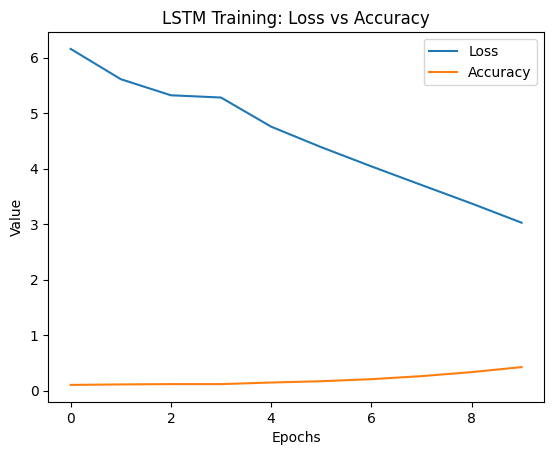

In [15]:
import matplotlib.pyplot as plt

plt.figure()

# Plot loss and accuracy
plt.plot(history.history['loss'], label='Loss')
plt.plot(history.history['accuracy'], label='Accuracy')

plt.title("LSTM Training: Loss vs Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Value")
plt.legend()

plt.show()

In [16]:
index_to_word = {v: k for k, v in tokenizer.word_index.items()}

def lstm_summary(input_text):
    seq = tokenizer.texts_to_sequences([input_text])
    seq = pad_sequences(seq, maxlen=max_article_len, padding='post')

    target_seq = np.zeros((1, 1))
    target_seq[0, 0] = tokenizer.word_index.get('startseq', 1)

    decoded_words = []

    for _ in range(max_summary_len):

        output = model.predict([seq, target_seq], verbose=0)
        idx = np.argmax(output[0, -1, :])

        word = index_to_word.get(idx, "")

        if word == "endseq":
            break

        if word != "":
            decoded_words.append(word)

        target_seq = np.append(target_seq, [[idx]], axis=1)

    return " ".join(decoded_words)

In [17]:
sample = test_data[0]
text = preprocess_text(sample['article'][:400])

print("Original Text:\n")
print(text)

print("\nLSTM SUMMARY:\n")
print(lstm_summary(text))

Original Text:

cnnthe palestinian authority officially became the 123rd member of the international criminal court on wednesday a step that gives the court jurisdiction over alleged crimes in palestinian territories the formal accession was marked with a ceremony at the hague in the netherlands where the court is based the palestinians signed the iccs founding rome statute in january when they also acce

LSTM SUMMARY:

is the us has be a capital one was been forced from the first of the postsoviet era


T5 MODEL

In [18]:
tokenizer_t5 = T5Tokenizer.from_pretrained("t5-small")
model_t5 = T5ForConditionalGeneration.from_pretrained("t5-small")

tokenizer_config.json:   0%|          | 0.00/2.32k [00:00<?, ?B/s]

spiece.model:   0%|          | 0.00/792k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.39M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/1.21k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/242M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/131 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]

In [19]:
def t5_summary(text):
    input_text = "summarize: " + text[:2000]

    inputs = tokenizer_t5.encode(input_text, return_tensors="pt", max_length=512, truncation=True)

    outputs = model_t5.generate(
        inputs,
        max_length=150,
        min_length=40,
        num_beams=4,
        length_penalty=2.0,
        no_repeat_ngram_size=3,
        early_stopping=True
    )

    summary = tokenizer_t5.decode(outputs[0], skip_special_tokens=True)
    return summary

In [20]:
sample = test_data[0]
text = preprocess_text(sample['article'][:400])

print("Original Text:\n")
print(text)

print("\nT5 SUMMARY:\n")
print(t5_summary(text))

Original Text:

cnnthe palestinian authority officially became the 123rd member of the international criminal court on wednesday a step that gives the court jurisdiction over alleged crimes in palestinian territories the formal accession was marked with a ceremony at the hague in the netherlands where the court is based the palestinians signed the iccs founding rome statute in january when they also acce

T5 SUMMARY:

cnn the palestinian authority officially becomes the 123rd member of the international criminal court. the formal accession was marked with a ceremony at the hague in the netherlands where the court is based.


SCORE EVALUATION

In [21]:
scorer = rouge_scorer.RougeScorer(['rouge1','rougeL'], use_stemmer=True)

def evaluate(func):
    scores = []

    for item in test_data:
        text = item['article'][:300]
        ref = item['highlights']

        try:
            gen = func(text)
            if len(gen.strip()) == 0:
                continue

            score = scorer.score(ref, gen)
            scores.append(score['rouge1'].fmeasure)
            scores.append(score['rougeL'].fmeasure)

        except:
            continue

    return np.mean(scores) if len(scores) > 0 else 0

In [22]:
print("TextRank running...")
tr_score = evaluate(textrank_summary)

print("LSTM running...")
lstm_score = evaluate(lstm_summary)

print("T5 running...")
t5_score = evaluate(t5_summary)

print("\nRESULTS:")
print("TextRank:", tr_score)
print("LSTM:", lstm_score)
print("T5:", t5_score)

TextRank running...
LSTM running...
T5 running...

RESULTS:
TextRank: 0.2556310460964999
LSTM: 0.10604038349808274
T5: 0.26747768662578886


comparison

In [23]:
scores = {
    "TextRank": tr_score,
    "LSTM": lstm_score,
    "T5": t5_score
}

best_model = max(scores, key=scores.get)

print("\n🏆 Best Model:", best_model)

print("\n📌 Best Summary:\n")

if best_model == "TextRank":
    print(textrank_summary(text))
elif best_model == "LSTM":
    print(lstm_summary(text))
else:
    print(t5_summary(text))


🏆 Best Model: T5

📌 Best Summary:

cnn the palestinian authority officially becomes the 123rd member of the international criminal court. the formal accession was marked with a ceremony at the hague in the netherlands where the court is based.


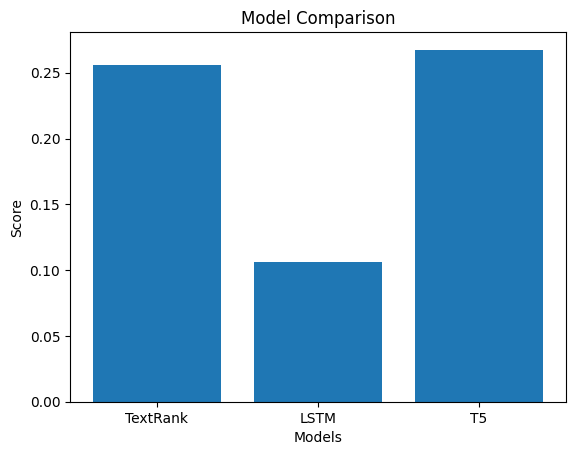

In [24]:
import matplotlib.pyplot as plt

models = ["TextRank", "LSTM", "T5"]
scores = [tr_score, lstm_score, t5_score]

plt.figure()
plt.bar(models, scores)

plt.title("Model Comparison")
plt.xlabel("Models")
plt.ylabel("Score")

plt.show()

USER TESTING

In [25]:
# --- Option A: running in Google Colab ---
from google.colab import files
uploaded = files.upload()

pdf_path = list(uploaded.keys())[0]
reader = PdfReader(pdf_path)

# --- Option B: running locally / not in Colab ---
# Comment out the block above and set pdf_path manually instead, e.g.:
# pdf_path = "my_document.pdf"
# reader = PdfReader(pdf_path)

Saving advanced topics of DBMS.pdf to advanced topics of DBMS.pdf


In [26]:
pdf_text = ""
for page in reader.pages:
    if page.extract_text():
        pdf_text += page.extract_text()

# Limit text (important for T5)
pdf_text = pdf_text[:2000]

In [27]:
def clean_text(text):
    text = text.lower()
    text = text.replace("\n", " ").replace("\t", " ")
    text = re.sub(r'[^a-zA-Z0-9.,!? ]', '', text)
    text = re.sub(r'\s+', ' ', text)
    return text.strip()

pdf_text = clean_text(pdf_text)

In [28]:
sentences = sent_tokenize(pdf_text)
sentences = [s for s in sentences if len(s.split()) > 3]

pdf_text = " ".join(sentences)

In [29]:
print("\n🏆 Best Model Selected:", best_model)

# Generate summary using best model
if best_model == "TextRank":
    best_summary = textrank_summary(pdf_text)

elif best_model == "LSTM":
    best_summary = lstm_summary(pdf_text)

else:
    best_summary = t5_summary(pdf_text)

best_summary
print("\nFINAL STUDY NOTES:\n")
print(best_summary)


🏆 Best Model Selected: T5

FINAL STUDY NOTES:

oodb provides all the facilities associated with object oriented paradigm. it enables us to create classes, organize objects, structure an inheritance hierarchy and call methods of other classes. a relational database can be used to store and manage objects.
